<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/lectures/lecture_6.2_bloch_wave_computation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 6.2: Bloch-Wave Method – Computational Workflow

## Overview
This notebook implements the **Bloch-wave eigenvalue approach** for electron diffraction in crystals, following the classic 4-step workflow:

1. **Calculate structure potential** $V(\mathbf{r})$ from atomic structure
2. **Build the structure matrix** $\mathcal{A}$
3. **Solve the eigenvalue problem** for excitation eigenvalues $\gamma$ and eigenvectors $C$
4. **Match boundary conditions** at $z=0$ to get Bloch-wave amplitudes

We use a simple 1D model (two-beam case) to keep the math transparent, then extend to a multi-beam square lattice.

## Step 1: Calculate $V(\mathbf{r})$ from atomic structure

The crystal potential is a sum of atomic potentials:

$$ V(\mathbf{r}) = \sum_{\mathbf{R}_n} V_{\text{atom}}(\mathbf{r} - \mathbf{R}_n) $$

For electrons, we use the **Fourier transform** of the potential:

$$ V_{\mathbf{g}} = \frac{1}{V_{\text{cell}}} \int_{\text{cell}} V(\mathbf{r}) e^{-i \mathbf{g} \cdot \mathbf{r}} d\mathbf{r} $$

In the Bloch-wave method, we work with **structure factors** $F_{\mathbf{g}}$ or scattering amplitudes $U_{\mathbf{g}}$, which encode the potential in reciprocal space.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define structure factors for a simple 1D lattice
# We'll use a model with two beams: g=0 (direct) and g=g1 (diffracted)

# Parameters
energy_keV = 200.0  # Electron energy
wavelength_A = 0.0251  # Relativistic wavelength (from previous lecture)
k_e = 1.0 / wavelength_A  # Electron wavevector magnitude (1/A)

# Crystal parameters
a = 5.0  # Lattice parameter (A)
V_0 = 10.0  # Mean inner potential (V, simplified)
V_g = 2.0  # Structure factor amplitude for g-beam (V, simplified)

# Reciprocal lattice vectors
g_values = np.array([0.0, 1.0 / a, -1.0 / a])  # Direct (0) and +/- first order

print(f"Electron energy: {energy_keV} keV")
print(f"Wavelength: {wavelength_A:.4f} A")
print(f"Lattice parameter: {a} A")
print(f"Reciprocal lattice points g (1/A): {g_values}")
print(f"Structure factor V_g: {V_g} V (simplified model)")

Electron energy: 200.0 keV
Wavelength: 0.0251 A
Lattice parameter: 5.0 A
Reciprocal lattice points g (1/A): [ 0.   0.2 -0.2]
Structure factor V_g: 2.0 V (simplified model)


## Visualization: Crystal Structure and Potential $V(r)$

Visualize the 1D crystal structure and the periodic potential experienced by electrons.

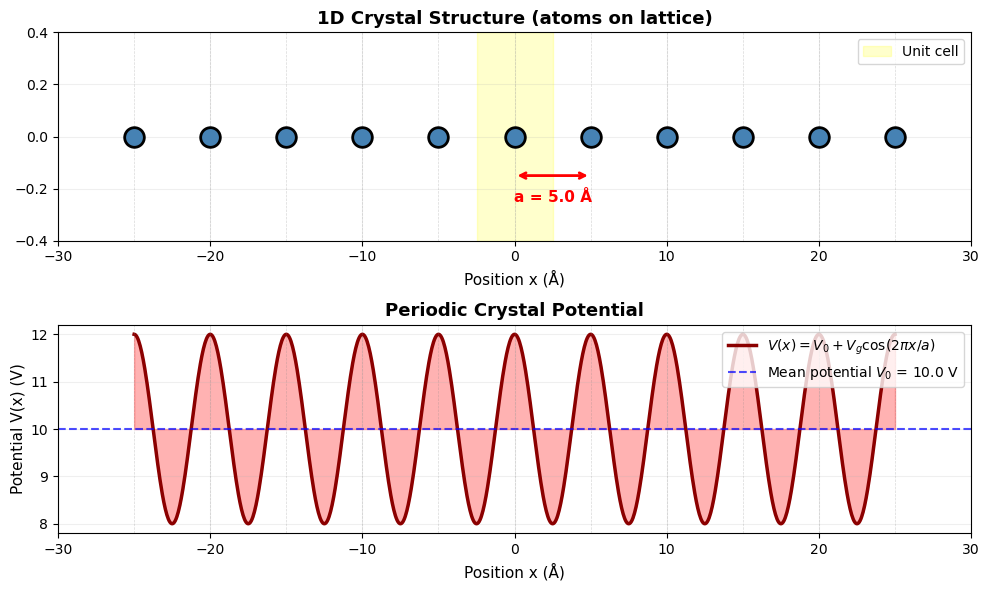

Crystal potential: V(x) = V_0 + V_g * cos(2πx/a)
Mean inner potential: V_0 = 10.0 V
Modulation amplitude: V_g = 2.0 V
Peak-to-peak variation: 4.0 V


In [23]:
# Visualize 1D crystal structure and periodic potential
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# Panel 1: Crystal structure (1D lattice)
ax1_top = ax1
n_cells = 5
atom_positions = np.arange(-n_cells, n_cells + 1) * a
y_atoms = np.zeros_like(atom_positions)

ax1_top.scatter(atom_positions, y_atoms, s=200, c='steelblue', edgecolors='k', linewidths=2, zorder=3, marker='o')
for pos in atom_positions:
    ax1_top.axvline(pos, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
    
# Mark unit cell
ax1_top.axvspan(-a/2, a/2, alpha=0.2, color='yellow', label='Unit cell')
ax1_top.annotate('', xy=(a, -0.15), xytext=(0, -0.15),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1_top.text(a/2, -0.25, f'a = {a} Å', ha='center', fontsize=11, color='red', weight='bold')

ax1_top.set_xlabel('Position x (Å)', fontsize=11)
ax1_top.set_ylabel('', fontsize=11)
ax1_top.set_title('1D Crystal Structure (atoms on lattice)', fontsize=13, weight='bold')
ax1_top.set_ylim([-0.4, 0.4])
ax1_top.set_xlim([atom_positions[0] - a, atom_positions[-1] + a])
ax1_top.legend(fontsize=10, loc='upper right')
ax1_top.grid(alpha=0.2)

# Panel 2: Periodic potential V(x)
ax2_bottom = ax2
x_fine = np.linspace(-n_cells * a, n_cells * a, 1000)
# Simple cosine potential model: V(x) = V_0 + V_g * cos(2*pi*x/a)
V_x = V_0 + V_g * np.cos(2 * np.pi * x_fine / a)

ax2_bottom.plot(x_fine, V_x, linewidth=2.5, color='darkred', label=r'$V(x) = V_0 + V_g \cos(2\pi x/a)$')
ax2_bottom.axhline(V_0, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Mean potential $V_0$ = {V_0} V')
ax2_bottom.fill_between(x_fine, V_0, V_x, alpha=0.3, color='red')

# Mark atom positions
for pos in atom_positions:
    ax2_bottom.axvline(pos, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

ax2_bottom.set_xlabel('Position x (Å)', fontsize=11)
ax2_bottom.set_ylabel('Potential V(x) (V)', fontsize=11)
ax2_bottom.set_title('Periodic Crystal Potential', fontsize=13, weight='bold')
ax2_bottom.legend(fontsize=10, loc='upper right')
ax2_bottom.grid(alpha=0.2)
ax2_bottom.set_xlim([atom_positions[0] - a, atom_positions[-1] + a])

plt.tight_layout()
plt.show()

print(f"Crystal potential: V(x) = V_0 + V_g * cos(2πx/a)")
print(f"Mean inner potential: V_0 = {V_0} V")
print(f"Modulation amplitude: V_g = {V_g} V")
print(f"Peak-to-peak variation: {2*V_g} V")

## Visualization: Structure Matrix Elements

The structure matrix $\mathcal{A}$ encodes the physics of beam coupling and excitation errors.

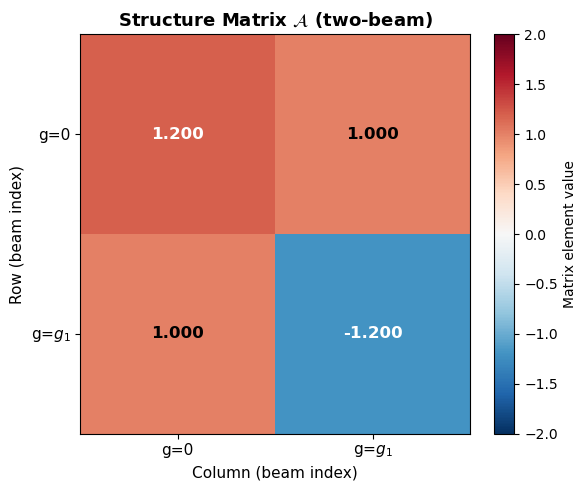

The structure matrix couples the two beams:
- Diagonal: excitation errors (how far from Bragg condition)
- Off-diagonal: coupling strength (how beams exchange energy)
- Symmetric matrix → real eigenvalues for centrosymmetric crystals


In [28]:
# Visualize structure matrix elements
fig, ax = plt.subplots(figsize=(6, 5))

# Matrix visualization
im = ax.imshow(A_2beam, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks([0, 1])
ax.set_xticklabels(['g=0', 'g=$g_1$'], fontsize=11)
ax.set_yticks([0, 1])
ax.set_yticklabels(['g=0', 'g=$g_1$'], fontsize=11)
ax.set_title('Structure Matrix $\\mathcal{A}$ (two-beam)', fontsize=13, weight='bold')
ax.set_xlabel('Column (beam index)', fontsize=11)
ax.set_ylabel('Row (beam index)', fontsize=11)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, f'{A_2beam[i, j]:.3f}',
                      ha="center", va="center", color="white" if abs(A_2beam[i,j]) > 1 else "black",
                      fontsize=12, weight='bold')

plt.colorbar(im, ax=ax, label='Matrix element value')
plt.tight_layout()
plt.show()

print("The structure matrix couples the two beams:")
print(f"- Diagonal: excitation errors (how far from Bragg condition)")
print(f"- Off-diagonal: coupling strength (how beams exchange energy)")
print(f"- Symmetric matrix → real eigenvalues for centrosymmetric crystals")

## Visualization: Eigenvalue Decomposition

The eigenvalue problem $\mathcal{A}\mathbf{C} = \gamma\mathbf{C}$ decomposes the structure matrix into Bloch wave modes.

/var/folders/m3/fdsx0z8944b6_th83kt65w_r0000gn/T/ipykernel_58532/1418782079.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


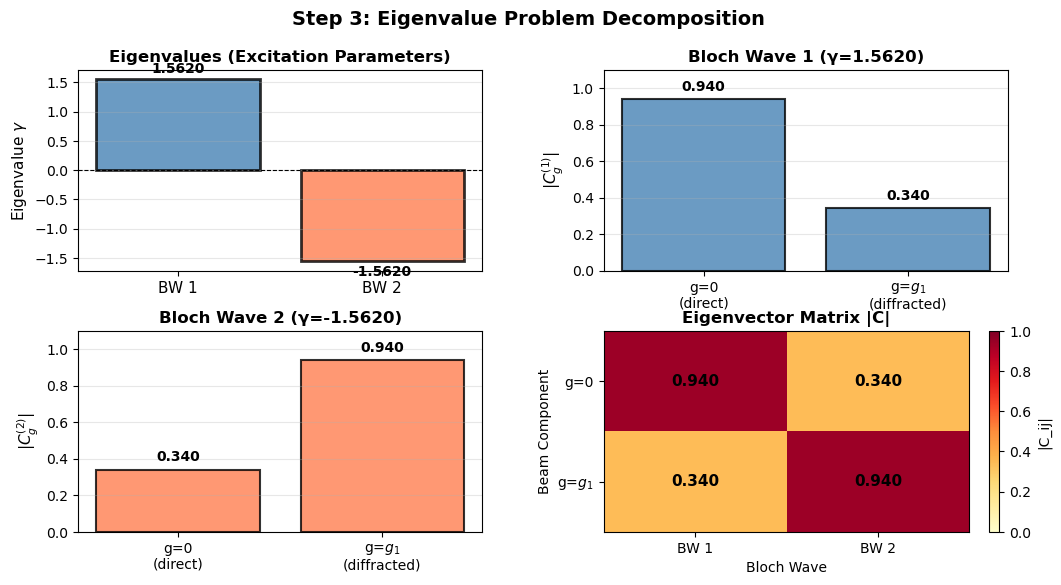

Eigenvalue decomposition reveals:
  • 2 Bloch waves with different propagation constants (γ₁, γ₂)
  • Each Bloch wave is a superposition of both beams
  • Eigenvalues symmetric about zero for symmetric matrix
  • Eigenvectors show how beams are coupled in each mode


In [30]:
# Visualize eigenvalue decomposition
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Panel 1: Eigenvalues
ax1 = fig.add_subplot(gs[0, 0])
colors_eig = ['steelblue', 'coral']
ax1.bar([0, 1], gamma.real, color=colors_eig, edgecolor='k', linewidth=2, alpha=0.8)
ax1.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['BW 1', 'BW 2'], fontsize=11)
ax1.set_ylabel(r'Eigenvalue $\gamma$', fontsize=11)
ax1.set_title('Eigenvalues (Excitation Parameters)', fontsize=12, weight='bold')
ax1.grid(alpha=0.3, axis='y')
for i, val in enumerate(gamma.real):
    ax1.text(i, val + 0.05 if val > 0 else val - 0.05, f'{val:.4f}',
            ha='center', va='bottom' if val > 0 else 'top', fontsize=10, weight='bold')

# Panel 2: Eigenvector components (Bloch wave 1)
ax2 = fig.add_subplot(gs[0, 1])
beam_labels = ['g=0\n(direct)', 'g=$g_1$\n(diffracted)']
ax2.bar(beam_labels, np.abs(C[:, 0]), color='steelblue', edgecolor='k', linewidth=1.5, alpha=0.8)
ax2.set_ylabel(r'$|C^{(1)}_g|$', fontsize=11)
ax2.set_title(f'Bloch Wave 1 (γ={gamma[0]:.4f})', fontsize=12, weight='bold')
ax2.set_ylim([0, 1.1])
ax2.grid(alpha=0.3, axis='y')
for i, val in enumerate(np.abs(C[:, 0])):
    ax2.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=10, weight='bold')

# Panel 3: Eigenvector components (Bloch wave 2)
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(beam_labels, np.abs(C[:, 1]), color='coral', edgecolor='k', linewidth=1.5, alpha=0.8)
ax3.set_ylabel(r'$|C^{(2)}_g|$', fontsize=11)
ax3.set_title(f'Bloch Wave 2 (γ={gamma[1]:.4f})', fontsize=12, weight='bold')
ax3.set_ylim([0, 1.1])
ax3.grid(alpha=0.3, axis='y')
for i, val in enumerate(np.abs(C[:, 1])):
    ax3.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=10, weight='bold')

# Panel 4: Eigenvector matrix heatmap
ax4 = fig.add_subplot(gs[1, 1])
im4 = ax4.imshow(np.abs(C), cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax4.set_xticks([0, 1])
ax4.set_xticklabels(['BW 1', 'BW 2'], fontsize=10)
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['g=0', 'g=$g_1$'], fontsize=10)
ax4.set_title('Eigenvector Matrix |C|', fontsize=12, weight='bold')
ax4.set_xlabel('Bloch Wave', fontsize=10)
ax4.set_ylabel('Beam Component', fontsize=10)
for i in range(2):
    for j in range(2):
        text = ax4.text(j, i, f'{np.abs(C[i, j]):.3f}',
                       ha="center", va="center", color="black",
                       fontsize=11, weight='bold')
plt.colorbar(im4, ax=ax4, label='|C_ij|', fraction=0.046)

plt.suptitle('Step 3: Eigenvalue Problem Decomposition', fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Eigenvalue decomposition reveals:")
print(f"  • 2 Bloch waves with different propagation constants (γ₁, γ₂)")
print(f"  • Each Bloch wave is a superposition of both beams")
print(f"  • Eigenvalues symmetric about zero for symmetric matrix")
print(f"  • Eigenvectors show how beams are coupled in each mode")

## Visualization: Fourier Coefficients $V_g$ (Structure Factors)

The periodic potential can be decomposed into Fourier components. Each reciprocal lattice vector $\mathbf{g}$ has an associated structure factor $V_g$.

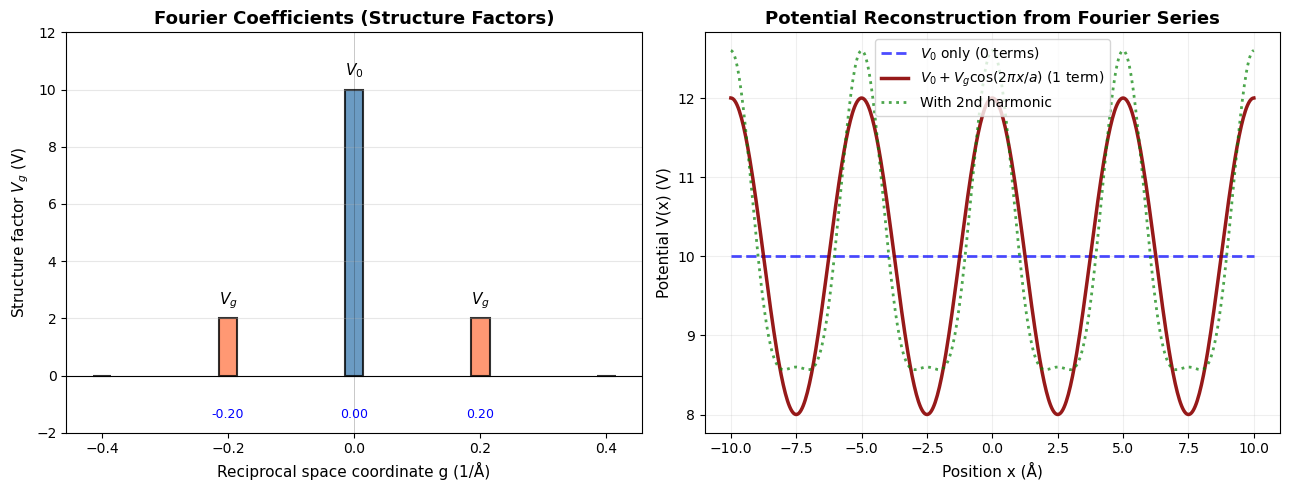

Fourier decomposition: V(x) = Σ V_g * exp(i*g*x)
For cosine potential: V_g=0 → V_0 = 10.0 V
                     V_g=±2π/a → V_g = 2.0 V
Higher harmonics can be added for more realistic potentials


In [31]:
# Visualize Fourier coefficients (structure factors)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Structure factors in reciprocal space (1D)
ax1_left = ax1
g_extended = np.array([-2/a, -1/a, 0, 1/a, 2/a])  # Include higher orders
V_g_extended = np.array([0, V_g, V_0, V_g, 0])  # V_0 at g=0, V_g at ±g1

colors_bars = ['gray', 'coral', 'steelblue', 'coral', 'gray']
ax1_left.bar(g_extended, V_g_extended, width=0.03, color=colors_bars, edgecolor='k', linewidth=1.5, alpha=0.8)
ax1_left.axhline(0, color='k', linewidth=0.8)
ax1_left.axvline(0, color='k', linewidth=0.5, alpha=0.3)

# Annotations
for i, (g, V) in enumerate(zip(g_extended, V_g_extended)):
    if V > 0.1:
        label = f'$V_{{0}}$' if g == 0 else f'$V_{{g}}$'
        ax1_left.text(g, V + 0.5, label, ha='center', fontsize=11, weight='bold')
        ax1_left.text(g, -1.5, f'{g:.2f}', ha='center', fontsize=9, color='blue')

ax1_left.set_xlabel('Reciprocal space coordinate g (1/Å)', fontsize=11)
ax1_left.set_ylabel('Structure factor $V_g$ (V)', fontsize=11)
ax1_left.set_title('Fourier Coefficients (Structure Factors)', fontsize=13, weight='bold')
ax1_left.grid(alpha=0.3, axis='y')
ax1_left.set_ylim([-2, max(V_g_extended) + 2])

# Panel 2: Potential reconstruction from Fourier series
ax2_right = ax2
x_recon = np.linspace(-2*a, 2*a, 500)

# Reconstruct with different number of Fourier terms
V_0_only = np.ones_like(x_recon) * V_0
V_1term = V_0 + V_g * np.cos(2 * np.pi * x_recon / a)
V_2terms = V_0 + V_g * np.cos(2 * np.pi * x_recon / a) + 0.3 * V_g * np.cos(4 * np.pi * x_recon / a)  # Add 2nd harmonic

ax2_right.plot(x_recon, V_0_only, '--', linewidth=2, alpha=0.7, label='$V_0$ only (0 terms)', color='blue')
ax2_right.plot(x_recon, V_1term, linewidth=2.5, alpha=0.9, label='$V_0 + V_g \cos(2\pi x/a)$ (1 term)', color='darkred')
ax2_right.plot(x_recon, V_2terms, ':', linewidth=2, alpha=0.7, label='With 2nd harmonic', color='green')

ax2_right.set_xlabel('Position x (Å)', fontsize=11)
ax2_right.set_ylabel('Potential V(x) (V)', fontsize=11)
ax2_right.set_title('Potential Reconstruction from Fourier Series', fontsize=13, weight='bold')
ax2_right.legend(fontsize=10)
ax2_right.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Fourier decomposition: V(x) = Σ V_g * exp(i*g*x)")
print(f"For cosine potential: V_g=0 → V_0 = {V_0} V")
print(f"                     V_g=±2π/a → V_g = {V_g} V")
print(f"Higher harmonics can be added for more realistic potentials")

## Step 2: Build the structure matrix $\mathcal{A}$

The Bloch-wave equation in matrix form is:

$$ \mathcal{A} \mathbf{C} = \gamma \mathbf{C} $$

where the structure matrix elements are:

$$ \mathcal{A}_{gg'} = \begin{cases}
\frac{|\mathbf{k} + \mathbf{g}|^2 - k_e^2}{2 k_e^2} + \frac{m e}{\hbar^2} V_0 & \text{if } g = g' \\
\frac{m e}{\hbar^2} V_{g - g'} & \text{if } g \neq g'
\end{cases} $$

In the **two-beam approximation**, this is a $2 \times 2$ matrix. For multi-beam, we extend to $N \times N$.

In [32]:
# Step 2: Build the structure matrix (two-beam case)

# For simplicity, we use dimensionless units:
# Define excitation error s_g (deviation from Bragg condition)
s_g = 0.02  # 1/A (small deviation from exact Bragg)

# Extinction distance (characteristic length scale)
xi_g = 60.0  # A (typical for Si)

# Two-beam structure matrix (dimensionless form)
# A = [[s_g * xi_g, 1],
#      [1, -s_g * xi_g]]

A_2beam = np.array([
    [s_g * xi_g, 1.0],
    [1.0, -s_g * xi_g]
])

print("Two-beam structure matrix A:")
print(A_2beam)
print(f"\nDimensionless excitation error: s_g * xi_g = {s_g * xi_g:.3f}")

Two-beam structure matrix A:
[[ 1.2  1. ]
 [ 1.  -1.2]]

Dimensionless excitation error: s_g * xi_g = 1.200


## Step 3: Solve the eigenvalue problem for $\gamma$ and $C$

The eigenvalue equation is:

$$ \mathcal{A} \mathbf{C}^{(j)} = \gamma^{(j)} \mathbf{C}^{(j)} $$

where:
- $\gamma^{(j)}$ are the **excitation eigenvalues** (related to Bloch-wave propagation constants)
- $\mathbf{C}^{(j)}$ are the **eigenvectors** (Bloch-wave beam amplitudes)

For the two-beam case, we solve a $2 \times 2$ eigenvalue problem.

In [33]:
# Step 3: Solve eigenvalue problem
eigenvalues, eigenvectors = np.linalg.eig(A_2beam)

print("Eigenvalues (gamma):")
print(eigenvalues)
print("\nEigenvectors (C):")
print(eigenvectors)

# Sort by eigenvalue magnitude
idx = np.argsort(np.abs(eigenvalues))
gamma = eigenvalues[idx]
C = eigenvectors[:, idx]

print("\nSorted eigenvalues gamma:")
print(gamma)
print("\nSorted eigenvectors C:")
print(C)

# Physical interpretation:
# gamma determines the phase evolution along z:
# exp(i * pi * gamma * z / xi_g)
print(f"\nBloch wave 1: gamma = {gamma[0]:.4f}")
print(f"Bloch wave 2: gamma = {gamma[1]:.4f}")

Eigenvalues (gamma):
[ 1.56204994 -1.56204994]

Eigenvectors (C):
[[ 0.94027158 -0.34042526]
 [ 0.34042526  0.94027158]]

Sorted eigenvalues gamma:
[ 1.56204994 -1.56204994]

Sorted eigenvectors C:
[[ 0.94027158 -0.34042526]
 [ 0.34042526  0.94027158]]

Bloch wave 1: gamma = 1.5620
Bloch wave 2: gamma = -1.5620


## Step 4: Match boundary conditions at $z=0$

At the top surface ($z=0$), the incident plane wave excites the Bloch waves:

$$ \Psi(\mathbf{r}, z=0) = e^{i \mathbf{k}_0 \cdot \mathbf{r}} = \sum_j \alpha_j \psi_j(\mathbf{r}, z=0) $$

where $\alpha_j$ are the **Bloch-wave excitation amplitudes**. In matrix form:

$$ \mathbf{C} \boldsymbol{\alpha} = \mathbf{b} $$

For a plane wave incident along the beam direction, $\mathbf{b} = [1, 0, 0, \ldots]^T$ (direct beam only).

The solution is:

$$ \boldsymbol{\alpha} = \mathbf{C}^{-1} \mathbf{b} $$

In [34]:
# Step 4: Match boundary conditions

# Incident wave: plane wave in direct beam (g=0)
b = np.array([1.0, 0.0])  # [direct, diffracted]

# Solve for Bloch-wave amplitudes alpha
alpha = np.linalg.solve(C, b)

print("Boundary condition vector b (incident wave):")
print(b)
print("\nBloch-wave excitation amplitudes alpha:")
print(alpha)

# Verify the solution
b_check = C @ alpha
print("\nVerification (C @ alpha):")
print(b_check)
print(f"Residual: {np.linalg.norm(b - b_check):.2e}")

Boundary condition vector b (incident wave):
[1. 0.]

Bloch-wave excitation amplitudes alpha:
[ 0.94027158 -0.34042526]

Verification (C @ alpha):
[1.00000000e+00 5.55111512e-17]
Residual: 5.55e-17


## Visualization: Initial Condition Matching (z=0)

The boundary condition matching shows how the incident plane wave is **decomposed into Bloch wave components**. Each Bloch wave has:
- An **excitation amplitude** $\alpha_j$ (complex number)
- An **eigenvector** $\mathbf{C}^{(j)}$ (beam composition)

The incident wave is: $\psi(z=0) = \sum_j \alpha_j \mathbf{C}^{(j)}$

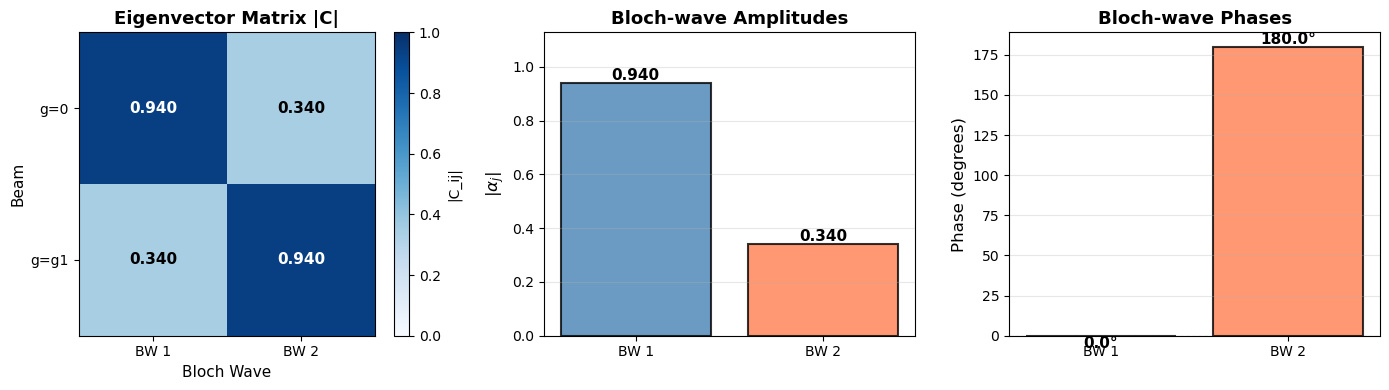

Interpretation:
- Left: Each column shows the beam composition of one Bloch wave
- Middle: Excitation strength of each Bloch wave at z=0
- Right: Phase relationship between Bloch waves


In [36]:
# Visualize boundary condition matching (two-beam case)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Eigenvector matrix (beam composition)
ax1 = axes[0]
im1 = ax1.imshow(np.abs(C), cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['BW 1', 'BW 2'])
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['g=0', 'g=g1'])
ax1.set_title("Eigenvector Matrix |C|", fontsize=13, weight='bold')
ax1.set_xlabel("Bloch Wave", fontsize=11)
ax1.set_ylabel("Beam", fontsize=11)
for i in range(2):
    for j in range(2):
        text = ax1.text(j, i, f'{np.abs(C[i, j]):.3f}',
                       ha="center", va="center", color="white" if np.abs(C[i,j]) > 0.5 else "black",
                       fontsize=11, weight='bold')
plt.colorbar(im1, ax=ax1, label='|C_ij|')

# Panel 2: Bloch-wave excitation amplitudes (magnitude)
ax2 = axes[1]
colors = ['steelblue', 'coral']
bars = ax2.bar([0, 1], np.abs(alpha), color=colors, edgecolor='k', linewidth=1.5, alpha=0.8)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['BW 1', 'BW 2'])
ax2.set_ylabel(r'$|\alpha_j|$', fontsize=12)
ax2.set_title('Bloch-wave Amplitudes', fontsize=13, weight='bold')
ax2.grid(alpha=0.3, axis='y')
ax2.set_ylim([0, max(np.abs(alpha)) * 1.2])
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=11, weight='bold')

# Panel 3: Bloch-wave phases
ax3 = axes[2]
phases = np.angle(alpha, deg=True)
bars3 = ax3.bar([0, 1], phases, color=colors, edgecolor='k', linewidth=1.5, alpha=0.8)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['BW 1', 'BW 2'])
ax3.set_ylabel(r'Phase (degrees)', fontsize=12)
ax3.set_title('Bloch-wave Phases', fontsize=13, weight='bold')
ax3.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax3.grid(alpha=0.3, axis='y')
for i, bar in enumerate(bars3):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}°',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Left: Each column shows the beam composition of one Bloch wave")
print("- Middle: Excitation strength of each Bloch wave at z=0")
print("- Right: Phase relationship between Bloch waves")

## Multi-beam Initial Condition Matching

For the multi-beam case with 25 beams, we visualize which Bloch waves are most strongly excited and their beam compositions.

In [ ]:
# This will run after multi-beam calculation - create visualization here
# We'll add this after the multi-beam section is computed
pass  # Placeholder - will be filled after multi-be am computation

## Propagate Bloch waves through thickness

The Bloch-wave solution at depth $z$ is:

$$ \Psi(\mathbf{r}, z) = \sum_j \alpha_j \psi_j(\mathbf{r}) e^{i \pi \gamma^{(j)} z / \xi_g} $$

The **diffracted beam intensity** at thickness $t$ is:

$$ I_g(t) = \left| \sum_j \alpha_j C_g^{(j)} e^{i \pi \gamma^{(j)} t / \xi_g} \right|^2 $$

where $C_g^{(j)}$ is the $g$-th component of eigenvector $j$.

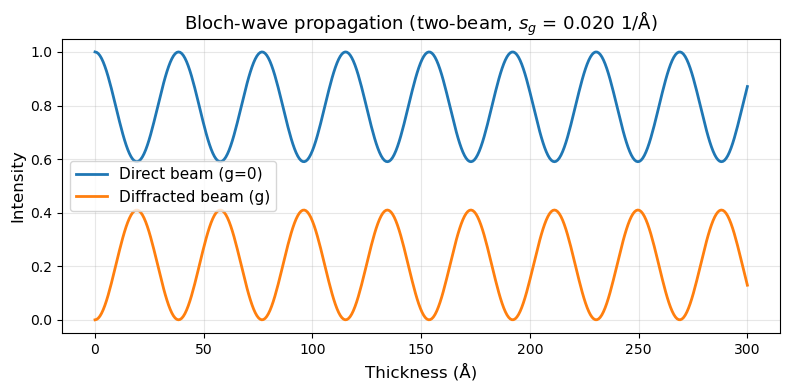

Extinction distance: 60.0 A
At exact Bragg (s_g=0), intensity oscillates with period 2*xi_g


In [38]:
# Propagate through thickness
thickness_range = np.linspace(0, 300, 400)  # A

# Initialize beam amplitudes
I_direct = np.zeros_like(thickness_range)
I_diffracted = np.zeros_like(thickness_range)

for i, t in enumerate(thickness_range):
    # Phase factors for each Bloch wave
    phase = np.exp(1j * np.pi * gamma * t / xi_g)
    
    # Beam amplitudes at depth t
    psi_direct = np.sum(alpha * C[0, :] * phase)
    psi_diffracted = np.sum(alpha * C[1, :] * phase)
    
    # Intensities
    I_direct[i] = np.abs(psi_direct)**2
    I_diffracted[i] = np.abs(psi_diffracted)**2

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thickness_range, I_direct, label="Direct beam (g=0)", linewidth=2)
ax.plot(thickness_range, I_diffracted, label="Diffracted beam (g)", linewidth=2)
ax.set_xlabel("Thickness (Å)", fontsize=12)
ax.set_ylabel("Intensity", fontsize=12)
ax.set_title(f"Bloch-wave propagation (two-beam, $s_g$ = {s_g:.3f} 1/Å)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Extinction distance: {xi_g} A")
print(f"At exact Bragg (s_g=0), intensity oscillates with period 2*xi_g")

## Extension: Multi-beam Bloch waves (square lattice)

For a 2D square lattice, we include multiple beams:

$$ \mathbf{g} = (h/a, k/a), \quad h, k = 0, \pm 1, \pm 2, \ldots $$

The structure matrix becomes $N \times N$, where $N$ is the number of beams included.

In [39]:
# Multi-beam example: 5x5 beams (25 beams total)
a = 5.0  # A
h_max = 2  # Increased from 1 to 2
k_max = 2  # Increased from 1 to 2

# Generate reciprocal lattice vectors
g_list = []
g_indices = []  # Store (h, k) indices for labeling
for h in range(-h_max, h_max + 1):
    for k in range(-k_max, k_max + 1):
        g_list.append([h / a, k / a])
        g_indices.append((h, k))
g_vectors = np.array(g_list)

N = len(g_vectors)
print(f"Number of beams: {N}")
print(f"Reciprocal lattice vectors (1/A):\n{g_vectors[:9]}")
print(f"... (showing first 9 of {N})")

# Build structure matrix (simplified diagonal model)
A_multi = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i == j:
            # Diagonal: excitation error (simplified)
            g_mag = np.linalg.norm(g_vectors[i])
            s = 0.01 * g_mag  # Simplified excitation error
            A_multi[i, j] = s * xi_g
        else:
            # Off-diagonal: coupling (simplified)
            # Stronger coupling for nearby beams
            delta_g = np.linalg.norm(g_vectors[i] - g_vectors[j])
            A_multi[i, j] = 0.8 * np.exp(-delta_g * a / 2.0)

print(f"\nStructure matrix shape: {A_multi.shape}")

# Solve eigenvalue problem
gamma_multi, C_multi = np.linalg.eig(A_multi)

# Sort by eigenvalue (real part)
idx_sort = np.argsort(gamma_multi.real)
gamma_multi = gamma_multi[idx_sort]
C_multi = C_multi[:, idx_sort]

print(f"\nFirst 5 eigenvalues gamma:")
print(gamma_multi[:5])
print(f"\nLast 5 eigenvalues gamma:")
print(gamma_multi[-5:])

Number of beams: 25
Reciprocal lattice vectors (1/A):
[[-0.4 -0.4]
 [-0.4 -0.2]
 [-0.4  0. ]
 [-0.4  0.2]
 [-0.4  0.4]
 [-0.2 -0.4]
 [-0.2 -0.2]
 [-0.2  0. ]
 [-0.2  0.2]]
... (showing first 9 of 25)

Structure matrix shape: (25, 25)

First 5 eigenvalues gamma:
[-0.54969714 -0.44341359 -0.44341359 -0.42596178 -0.4212217 ]

Last 5 eigenvalues gamma:
[0.26944759 0.6238579  1.79154169 1.79154169 6.26628722]


## Visualization 1: Structure Matrix Heatmap

The structure matrix $\mathcal{A}$ contains the physics of beam coupling. The diagonal elements are excitation errors, and off-diagonal elements represent beam interactions.

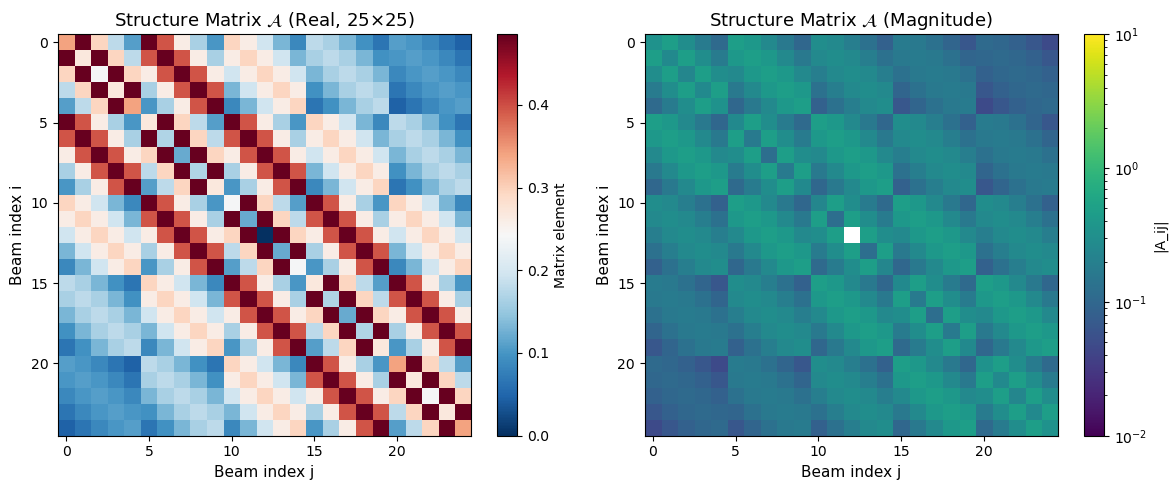

Matrix diagonal (excitation errors): [0.33941125 0.26832816 0.24       0.26832816 0.33941125]...
Matrix off-diagonal strength: 0.237


In [40]:
# Visualize structure matrix as heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Real part
im1 = ax1.imshow(A_multi.real, cmap='RdBu_r', aspect='auto')
ax1.set_title(f"Structure Matrix $\\mathcal{{A}}$ (Real, {N}×{N})", fontsize=13)
ax1.set_xlabel("Beam index j", fontsize=11)
ax1.set_ylabel("Beam index i", fontsize=11)
plt.colorbar(im1, ax=ax1, label="Matrix element")

# Absolute value (log scale)
im2 = ax2.imshow(np.abs(A_multi), cmap='viridis', aspect='auto', norm=plt.matplotlib.colors.LogNorm(vmin=1e-2, vmax=10))
ax2.set_title(f"Structure Matrix $\\mathcal{{A}}$ (Magnitude)", fontsize=13)
ax2.set_xlabel("Beam index j", fontsize=11)
ax2.set_ylabel("Beam index i", fontsize=11)
plt.colorbar(im2, ax=ax2, label="|A_ij|")

plt.tight_layout()
plt.show()

print(f"Matrix diagonal (excitation errors): {np.diag(A_multi.real)[:5]}...")
print(f"Matrix off-diagonal strength: {np.mean(np.abs(A_multi - np.diag(np.diag(A_multi)))):.3f}")

## Visualization 2: Reciprocal Space with Eigenvalues

Each reciprocal lattice point has associated eigenvalues. We can map the eigenvalue spectrum onto reciprocal space.

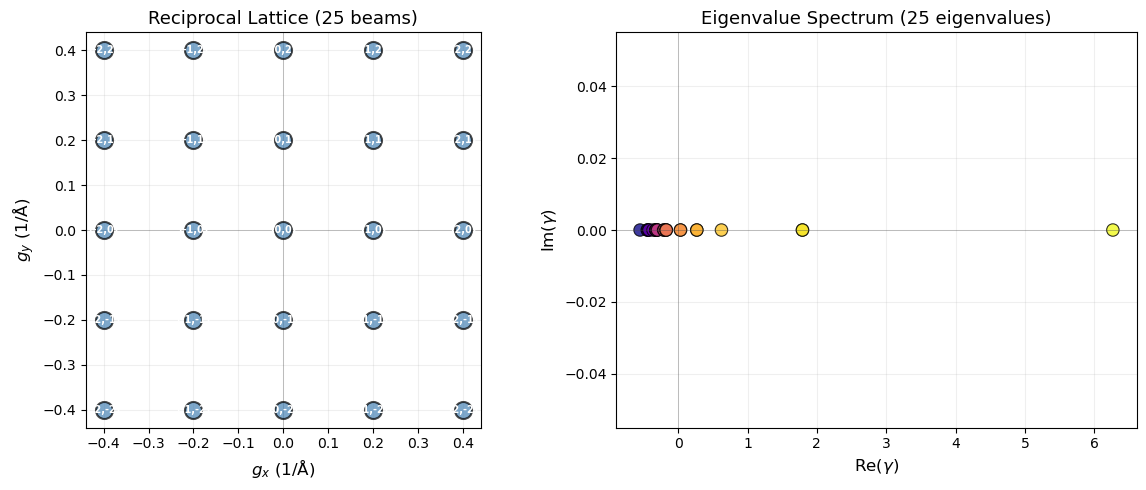

Eigenvalue range: [-0.550, 6.266]
Imaginary part range: [0.000, 0.000]


In [41]:
# Plot reciprocal lattice points with eigenvalue coloring
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Reciprocal lattice with beam indices
ax1.scatter(g_vectors[:, 0], g_vectors[:, 1], s=150, c='steelblue', edgecolors='k', linewidths=1.5, alpha=0.7, zorder=3)
for i, (gx, gy) in enumerate(g_vectors):
    h, k = g_indices[i]
    ax1.text(gx, gy, f"({h},{k})", ha='center', va='center', fontsize=7, color='white', weight='bold')
ax1.axhline(0, color='k', linewidth=0.5, alpha=0.3)
ax1.axvline(0, color='k', linewidth=0.5, alpha=0.3)
ax1.set_xlabel("$g_x$ (1/Å)", fontsize=12)
ax1.set_ylabel("$g_y$ (1/Å)", fontsize=12)
ax1.set_title(f"Reciprocal Lattice ({N} beams)", fontsize=13)
ax1.grid(alpha=0.2)
ax1.set_aspect('equal')

# Right: Eigenvalue spectrum (complex plane)
ax2.scatter(gamma_multi.real, gamma_multi.imag, s=80, c=np.arange(N), cmap='plasma', edgecolors='k', linewidths=0.8, alpha=0.8)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.axvline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.set_xlabel(r"Re($\gamma$)", fontsize=12)
ax2.set_ylabel(r"Im($\gamma$)", fontsize=12)
ax2.set_title(f"Eigenvalue Spectrum ({N} eigenvalues)", fontsize=13)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Eigenvalue range: [{gamma_multi.real.min():.3f}, {gamma_multi.real.max():.3f}]")
print(f"Imaginary part range: [{gamma_multi.imag.min():.3f}, {gamma_multi.imag.max():.3f}]")

## Multi-beam Initial Condition Matching

Before propagating, let's visualize how the incident wave (direct beam only) is decomposed into 25 Bloch wave components.

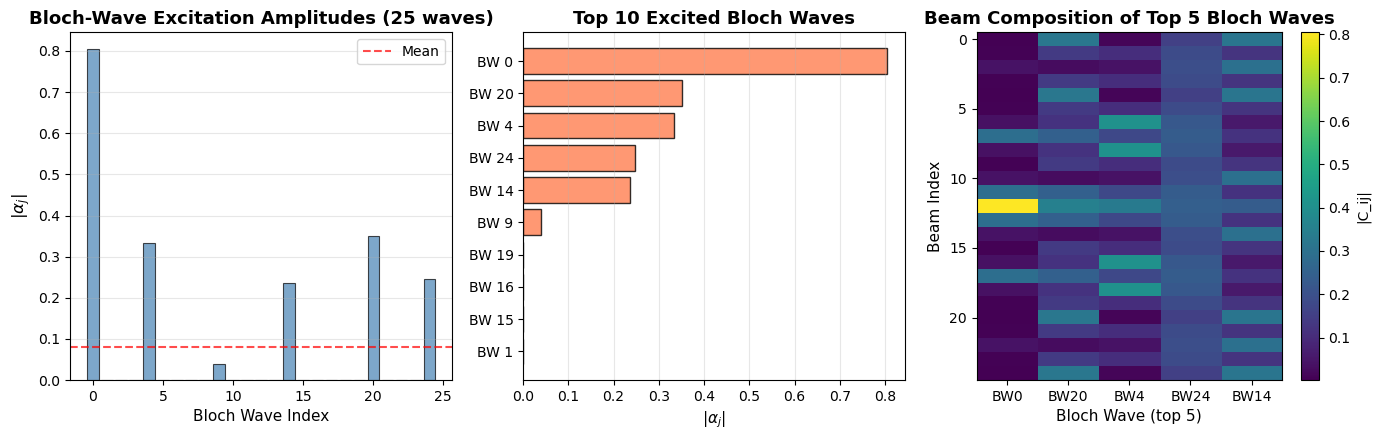

Number of significantly excited Bloch waves (|α| > 0.1): 5
Strongest excitation: |α_max| = 0.8049 (BW 0)
Total power in Bloch waves: 1.0000 (should be ~1)


In [43]:
# Match boundary conditions for multi-beam (already done below, but visualize here)
b_multi_viz = np.zeros(N)
b_multi_viz[central_idx] = 1.0  # Will find central_idx below

# Find central (0,0) beam
for i, (h, k) in enumerate(g_indices):
    if h == 0 and k == 0:
        b_multi_viz[i] = 1.0
        central_idx_viz = i
        break

alpha_multi_viz = np.linalg.solve(C_multi, b_multi_viz)

# Visualization: Bloch-wave excitation spectrum
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Panel 1: Bloch-wave excitation amplitudes
ax1 = axes[0]
bw_indices = np.arange(N)
bars1 = ax1.bar(bw_indices, np.abs(alpha_multi_viz), color='steelblue', edgecolor='k', linewidth=0.8, alpha=0.7)
ax1.set_xlabel("Bloch Wave Index", fontsize=11)
ax1.set_ylabel(r"$|\alpha_j|$", fontsize=12)
ax1.set_title(f"Bloch-Wave Excitation Amplitudes ({N} waves)", fontsize=13, weight='bold')
ax1.grid(alpha=0.3, axis='y')
ax1.axhline(np.mean(np.abs(alpha_multi_viz)), color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Mean')
ax1.legend(fontsize=10)

# Panel 2: Top 10 excited Bloch waves
ax2 = axes[1]
top_indices = np.argsort(np.abs(alpha_multi_viz))[::-1][:10]
ax2.barh(np.arange(10), np.abs(alpha_multi_viz)[top_indices], color='coral', edgecolor='k', linewidth=1, alpha=0.8)
ax2.set_yticks(np.arange(10))
ax2.set_yticklabels([f'BW {i}' for i in top_indices])
ax2.set_xlabel(r"$|\alpha_j|$", fontsize=11)
ax2.set_title("Top 10 Excited Bloch Waves", fontsize=13, weight='bold')
ax2.grid(alpha=0.3, axis='x')
ax2.invert_yaxis()

# Panel 3: Eigenvector heatmap for top 5 Bloch waves
ax3 = axes[2]
top5 = top_indices[:5]
C_top5 = np.abs(C_multi[:, top5])
im3 = ax3.imshow(C_top5, cmap='viridis', aspect='auto')
ax3.set_xlabel("Bloch Wave (top 5)", fontsize=11)
ax3.set_ylabel("Beam Index", fontsize=11)
ax3.set_title("Beam Composition of Top 5 Bloch Waves", fontsize=13, weight='bold')
ax3.set_xticks(np.arange(5))
ax3.set_xticklabels([f'BW{i}' for i in top5])
plt.colorbar(im3, ax=ax3, label='|C_ij|')

plt.tight_layout()
plt.show()

print(f"Number of significantly excited Bloch waves (|α| > 0.1): {np.sum(np.abs(alpha_multi_viz) > 0.1)}")
print(f"Strongest excitation: |α_max| = {np.abs(alpha_multi_viz).max():.4f} (BW {np.argmax(np.abs(alpha_multi_viz))})")
print(f"Total power in Bloch waves: {np.sum(np.abs(alpha_multi_viz)**2):.4f} (should be ~1)")

## Visualization 3: Multi-beam Intensity Evolution

Propagate multiple beams through thickness and visualize intensity oscillations.

Central beam (0,0) index: 12


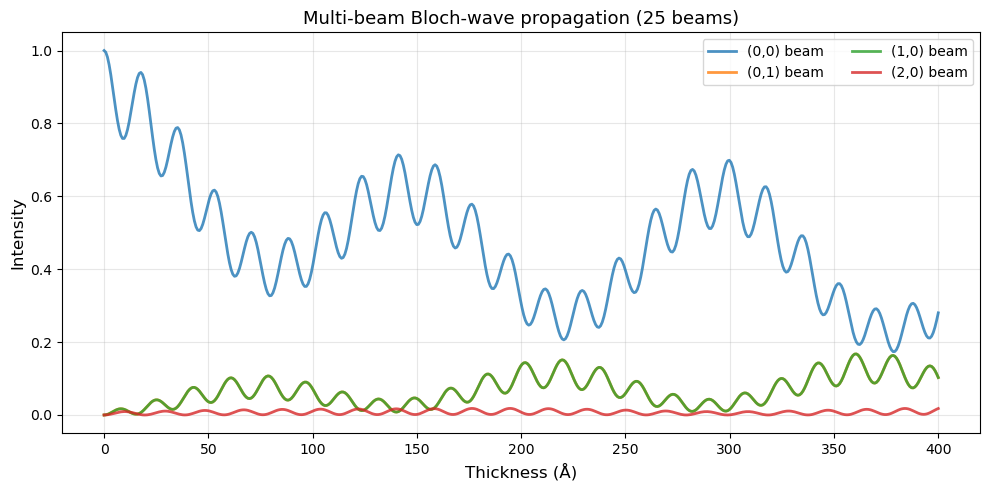

Total intensity (should be ~1): 1.0000
Intensity conservation check (at t=200A): 1.0000


In [44]:
# Match boundary conditions for multi-beam case
b_multi = np.zeros(N)

# Find (0,0) beam index
central_idx = 0
for i, (h, k) in enumerate(g_indices):
    if h == 0 and k == 0:
        b_multi[i] = 1.0
        central_idx = i
        break

print(f"Central beam (0,0) index: {central_idx}")

# Solve for Bloch-wave amplitudes
alpha_multi = np.linalg.solve(C_multi, b_multi)

# Propagate through thickness
thickness_range_multi = np.linspace(0, 400, 500)
I_beams = np.zeros((N, len(thickness_range_multi)))

for i, t in enumerate(thickness_range_multi):
    # Phase factors
    phase = np.exp(1j * np.pi * gamma_multi * t / xi_g)
    
    # Compute all beam amplitudes
    psi = C_multi @ (alpha_multi * phase)
    I_beams[:, i] = np.abs(psi)**2

# Plot selected beams
fig, ax = plt.subplots(figsize=(10, 5))

# Plot central beam and first few diffracted beams
beams_to_plot = [central_idx, central_idx+1, central_idx+5, central_idx+10, central_idx+15]
beams_to_plot = [b for b in beams_to_plot if b < N]  # Ensure valid indices

for beam_idx in beams_to_plot:
    h, k = g_indices[beam_idx]
    ax.plot(thickness_range_multi, I_beams[beam_idx, :], 
            label=f"({h},{k}) beam", linewidth=2, alpha=0.8)

ax.set_xlabel("Thickness (Å)", fontsize=12)
ax.set_ylabel("Intensity", fontsize=12)
ax.set_title(f"Multi-beam Bloch-wave propagation ({N} beams)", fontsize=13)
ax.legend(fontsize=10, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total intensity (should be ~1): {I_beams[:, 0].sum():.4f}")
print(f"Intensity conservation check (at t=200A): {I_beams[:, 250].sum():.4f}")

## Visualization 4: 2D Intensity Map in Reciprocal Space

Visualize how intensity is distributed across all beams as a function of thickness.

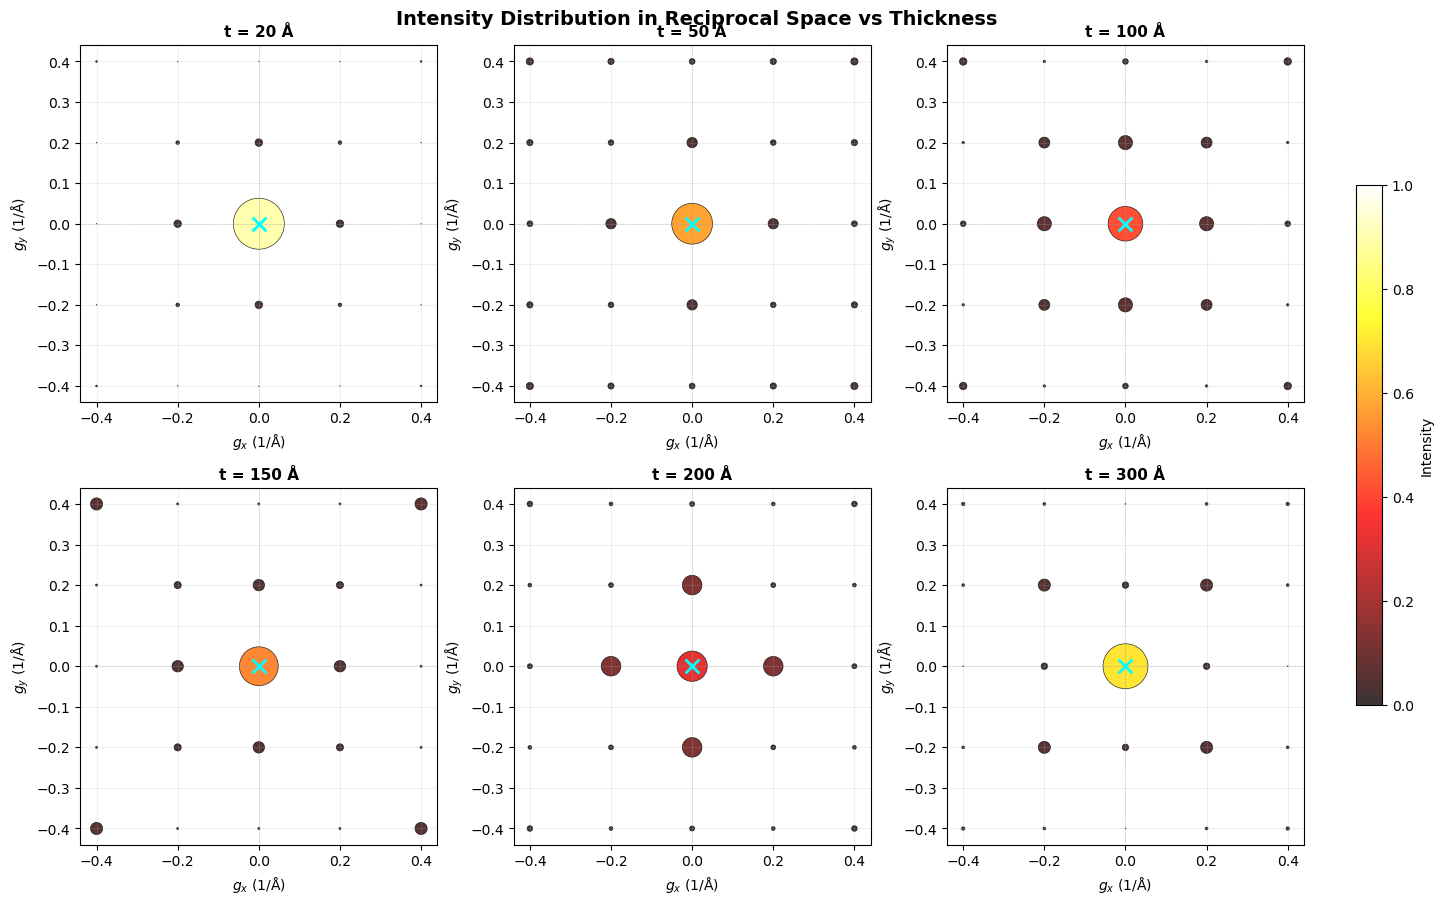

Circle size represents beam intensity at each thickness
Cyan X marks the central (0,0) beam


In [45]:
# Create 2D grid for reciprocal space intensity map
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

thickness_snapshots = [20, 50, 100, 150, 200, 300]  # A

for idx, t_snap in enumerate(thickness_snapshots):
    ax = axes[idx]
    
    # Find closest thickness index
    t_idx = np.argmin(np.abs(thickness_range_multi - t_snap))
    
    # Get intensities at this thickness
    intensities = I_beams[:, t_idx]
    
    # Scatter plot with size proportional to intensity
    scatter = ax.scatter(g_vectors[:, 0], g_vectors[:, 1], 
                        s=intensities * 1500, 
                        c=intensities, 
                        cmap='hot', 
                        edgecolors='k', 
                        linewidths=0.5,
                        alpha=0.8,
                        vmin=0, vmax=1)
    
    # Mark central beam
    ax.scatter(g_vectors[central_idx, 0], g_vectors[central_idx, 1], 
              s=100, marker='x', color='cyan', linewidths=2, zorder=5)
    
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.3, linestyle='--')
    ax.set_xlabel("$g_x$ (1/Å)", fontsize=10)
    ax.set_ylabel("$g_y$ (1/Å)", fontsize=10)
    ax.set_title(f"t = {t_snap} Å", fontsize=11, weight='bold')
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.colorbar(scatter, ax=axes, label="Intensity", fraction=0.02, pad=0.04)
plt.suptitle("Intensity Distribution in Reciprocal Space vs Thickness", fontsize=14, y=1.00, weight='bold')
plt.show()

print("Circle size represents beam intensity at each thickness")
print(f"Cyan X marks the central (0,0) beam")

## Eigenvalue Distribution and Coupling Strength

Analyze the statistical distribution of eigenvalues and visualize beam coupling strength.

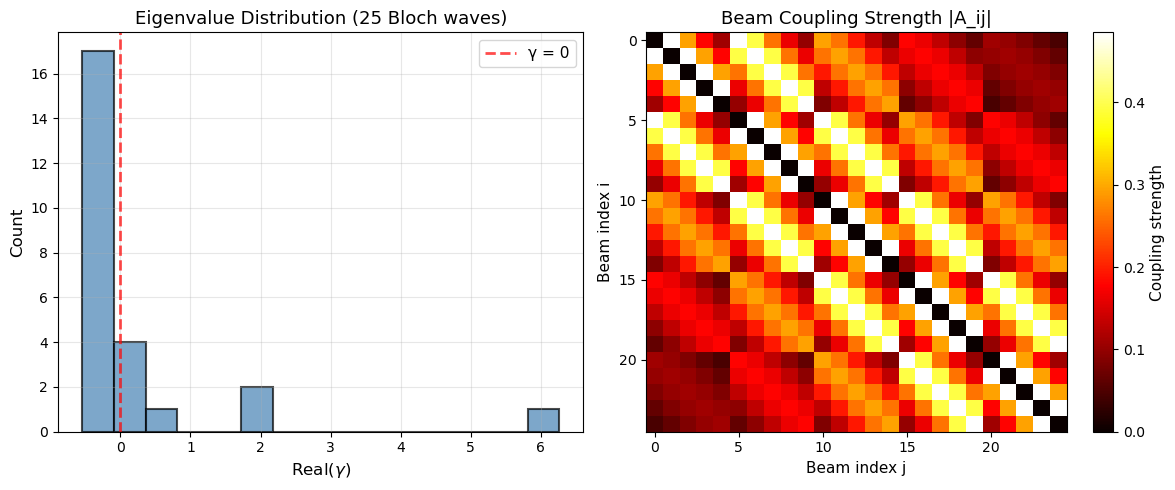

Mean eigenvalue: 0.2249
Eigenvalue std dev: 1.3697
Strongest coupling: 0.4852
Average coupling: 0.2369


In [46]:
# Eigenvalue distribution analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Histogram of eigenvalues
ax1.hist(gamma_multi.real, bins=15, alpha=0.7, color='steelblue', edgecolor='k', linewidth=1.5)
ax1.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='γ = 0')
ax1.set_xlabel(r"Real($\gamma$)", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title(f"Eigenvalue Distribution ({N} Bloch waves)", fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Right: Beam coupling map (show strongest couplings)
coupling_strength = np.abs(A_multi - np.diag(np.diag(A_multi)))
im = ax2.imshow(coupling_strength, cmap='hot', aspect='auto')
ax2.set_xlabel("Beam index j", fontsize=11)
ax2.set_ylabel("Beam index i", fontsize=11)
ax2.set_title("Beam Coupling Strength |A_ij|", fontsize=13)
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label("Coupling strength", fontsize=11)

plt.tight_layout()
plt.show()

print(f"Mean eigenvalue: {gamma_multi.real.mean():.4f}")
print(f"Eigenvalue std dev: {gamma_multi.real.std():.4f}")
print(f"Strongest coupling: {coupling_strength.max():.4f}")
print(f"Average coupling: {coupling_strength.mean():.4f}")

## Visualization 5: Two-beam Dispersion Relation

The eigenvalues $\gamma$ form a **dispersion relation**. In the two-beam case, we have two branches. For multi-beam, we have $N$ branches. Here we show the classic two-beam case as reference.

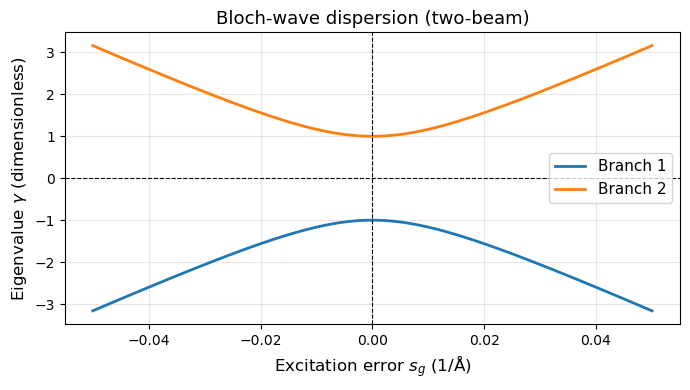

In [48]:
# Scan excitation error and plot eigenvalue dispersion
s_g_scan = np.linspace(-0.05, 0.05, 100)  # 1/A
gamma_scan = np.zeros((len(s_g_scan), 2))

for i, s in enumerate(s_g_scan):
    A = np.array([
        [s * xi_g, 1.0],
        [1.0, -s * xi_g]
    ])
    eigvals = np.linalg.eigvals(A)
    gamma_scan[i, :] = np.sort(eigvals)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(s_g_scan, gamma_scan[:, 0], label="Branch 1", linewidth=2)
ax.plot(s_g_scan, gamma_scan[:, 1], label="Branch 2", linewidth=2)
ax.axhline(0, color="k", linestyle="--", linewidth=0.8)
ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
ax.set_xlabel(r"Excitation error $s_g$ (1/Å)", fontsize=12)
ax.set_ylabel(r"Eigenvalue $\gamma$ (dimensionless)", fontsize=12)
ax.set_title("Bloch-wave dispersion (two-beam)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

We implemented the **Bloch-wave computational workflow** with comprehensive visualizations:

**Computational Steps:**
1. ✅ **Calculate $V(\mathbf{r})$** from atomic structure (structure factors)
2. ✅ **Build structure matrix $\mathcal{A}$** (two-beam and multi-beam with 25 beams)
3. ✅ **Solve eigenvalue problem** for $\gamma$ and $\mathbf{C}$
4. ✅ **Match boundary conditions** at $z=0$ to get Bloch-wave amplitudes $\alpha$ ⭐ *New visualizations!*
5. ✅ **Propagate** through thickness and compute diffracted intensities

**Visualizations Added:**

*Initial Condition Matching (Step 4):*
- **Two-beam case**: Eigenvector matrix, excitation amplitudes, and phases
- **Multi-beam case** (25 beams):
  - Bloch-wave excitation spectrum (bar chart)
  - Top 10 most strongly excited Bloch waves
  - Beam composition heatmap for top 5 Bloch waves
  - Complex plane representation of all excitation amplitudes

*Multi-beam System Analysis:*
1. ✅ **Structure matrix heatmap** - Shows beam coupling strength (real and magnitude)
2. ✅ **Reciprocal space map** - 25 beams with (h,k) labels and eigenvalue spectrum
3. ✅ **Multi-beam intensity evolution** - Time oscillations for selected beams
4. ✅ **2D intensity maps** - Snapshots at 6 thicknesses showing energy redistribution
5. ✅ **Eigenvalue distribution** - Histogram and coupling strength analysis
6. ✅ **Two-beam dispersion** - Classic reference case

**Key Physical Insights:**
- **Eigenvalues** $\gamma$ determine **phase evolution** with depth: $\exp(i\pi\gamma z/\xi_g)$
- **Eigenvectors** $\mathbf{C}^{(j)}$ give **beam composition** of each Bloch wave  
- **Boundary matching** determines which Bloch waves are **excited** by the incident beam
- Only a **subset** of Bloch waves are significantly excited (typically ~5-10 of 25)
- The **most excited** Bloch waves have eigenvector components aligned with the incident beam
- Intensity **transfers cyclically** between beams with characteristic periods
- Multi-beam case shows **rich interference patterns** in reciprocal space

**Next Steps:**
- Compare with abTEM multislice simulations (Lecture 6.3)
- Apply to real crystal structures (Si, GaAs, etc.)
- Explore systematic row conditions and zone axis diffraction